# Build a Mini-ACMED In 15 Minutes
### From Job Descriptions To ISIC Codes, With A Human In The Loop

## Why This Notebook?
You have just seen **ACMED**, the AI system NISR uses to code survey descriptions of economic
activity into **ISIC Rev.4**. It can look like something only a large technology company could build.
It isn't. In this notebook you build a working **prototype** of the same system, with the same recipe
as production, in about 15 minutes and a few dozen lines of code:

**raw survey text → cleaning → TF-IDF features → LinearSVC → calibrated confidence → confidence routing**

Everything here runs on free, open-source tools. The core is
[**scikit-learn**](https://scikit-learn.org), a free, open-source Python library for machine learning
used by researchers, governments and industry worldwide. Training the model itself
takes **about 10 lines** of code.

## What You Will Learn
1. **Building a prototype AI system is within reach of a national statistics office.** It needs no special
   hardware, no licences and no vendor, just a laptop or a free Google account.
2. **Most of the work is in the data, not the model.** Cleaning, removing duplicates and protecting
   personal information are decisions someone must make and be able to explain.
3. **How to judge a model honestly:** why *Macro F1* matters more than accuracy when some categories are rare.
4. **Confidence thresholds are a policy choice.** At the end, **you set them yourself** and see how
   they trade automation against errors that no human checks.

> **A prototype is not a production system.** What turns this notebook into ACMED is everything
> around the model: the far larger training data, validation, secure hosting, human review, monitoring
> and institutional ownership. Those are governance questions, not coding ones.

## How To Run It
Work through the notebook **one cell at a time**. Click a cell and press **Shift + Enter** to run it.
Colab then moves you to the next cell. Read the explanation above each cell first, then run it and
look at the result. Section by section, you will see the system being built.

* **The first time you run a cell**, Colab may warn that *"This notebook was not authored by Google"*.
  Click **Run anyway**.
* **Some cells hide their code** and show only a title. They still run with Shift + Enter, and you can
  click **Show code** to see what's inside.
* **If you fall behind**, click **Runtime → Run all** to catch up. The whole notebook runs in under a minute.

No installation is needed, and you don't need to understand the code to follow along.

## About The Data
* **Source:** about 35,000 free-text descriptions of economic activity from Rwanda's
  **Labour Force Survey**, collected by NISR.
* **Language:** mostly Kinyarwanda, with a little English and French. The descriptions are exactly as enumerators
  typed them, with typos and mixed capitals.
* **Labels:** each description was coded to **ISIC Rev.4** by a human coder. These human decisions are
  what the model learns from.
*

## 0 · Setup
All the libraries this notebook uses. Everything is already installed in Colab.

In [6]:
#@title Imports
# ====
# Imports
# ====
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, make_union
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

warnings.filterwarnings("ignore")

# ====
# Column names (the data file's headers are upper-cased on load)
# ====
DESCRIPTION = "ACTIVITY_DESCRIPTION"      # free-text description as typed by the enumerator
ISIC_CODE = "ISIC_CODE"                   # code assigned by a human coder
ISIC_TITLE = "ISIC_DESCRIPTION_FINAL"     # official ISIC title for the code
CLEAN = "CLEAN_DESCRIPTION"               # normalised text, created in Section 2
ISIC_LABEL = "ISIC_LABEL"                 # short English name, created in Section 2

## 1 · Load The Raw Data
Each row is a free-text description exactly as the enumerator typed it, plus the ISIC code
a human coder assigned. These human-coded rows are what the model learns from. Notice the mixed
capitals, typos and punctuation.

In [7]:
#@title Load the raw data { display-mode: "form" }
DATA_URL = "https://raw.githubusercontent.com/dmatekenya/isic-classifier-demo/main/data/isic_v1_train_sample.csv"
LOCAL = "acmed_demo_raw.csv"
raw = pd.read_csv(LOCAL if os.path.exists(LOCAL) else DATA_URL)
raw.columns = raw.columns.str.upper()

# ====
# Short English names for the codes used in the charts
# ====
SHORT = {"0111": "Growing cereals & legumes", "0113": "Growing vegetables & tubers", "1061": "Grain milling",
         "1410": "Tailoring & clothing making", "4630": "Wholesale of food & drinks", "4711": "General shop, mainly food",
         "4719": "General shop, other goods", "4721": "Specialised food shop", "4752": "Hardware & paint shop",
         "4771": "Clothing & shoe shop", "4772": "Pharmacy & cosmetics shop", "4773": "Other specialised shop",
         "4781": "Market stall: food & drinks", "4782": "Market stall: clothing", "4799": "Street & mobile vending",
         "5610": "Restaurants & food service", "5630": "Bars & beverage serving", "8510": "Primary education",
         "9602": "Hairdressing & beauty", "9810": "Household own-use production"}

# ====
# Shared chart style
# ====
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#898781", "#e1e0d9"
TIER_COLORS = {"Auto-coded": "#184f95", "Supervisor review": "#2a78d6", "Manual coding": "#86b6ef"}
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": INK, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

print(f"{len(raw):,} raw records · {raw[ISIC_CODE].nunique()} distinct ISIC codes\n")
raw[[DESCRIPTION, ISIC_CODE]].sample(8, random_state=7)

34,868 raw records · 324 distinct ISIC codes



,ACTIVITY_DESCRIPTION,ISIC_CODE
2907,UBUHINZI BW'IBIRAYI,113
29767,kogosha umisatsi,9602
7839,BAHINGA IBISHYIMBO,111
2543,ubudandazi bwibikoresho byimodoka byakoze higa...,4540
21337,UBUHINZI BW'IBISHYIMBO,111
17271,kuranguza hinganjemo imyenda,4771
3394,ubucuruzi budandaza higanjemo imyenda yabana n...,4771
13643,GUTWARA ABAGENZI MUMODOKA,4922


## 2 · Clean And Prepare The Data
In real projects, most of the effort goes here rather than into the model. There are six steps,
and each one is a decision that someone should be able to explain and audit:

1. **Normalise the text:** lowercase it and remove punctuation and stray symbols.
2. **Fix the codes:** *0111* is often stored as *111* once a spreadsheet drops the leading zero.
3. **Screen for personal names:** descriptions sometimes include the owner's name
   (*"boutique ya …"*). This is a **data-protection step**.
4. **Remove duplicates:** the same description repeated thousands of times would teach the model
   nothing new and would **inflate the test score**.
5. **Keep the 20 most common codes** so that a 15-minute demo has enough examples of each.
6. **Take a balanced sample of about 5,000 records**, keeping the natural imbalance but guaranteeing
   every code at least 80 examples.

In [8]:
#@title Clean and prepare the data (the code is the lesson, so it stays visible)
funnel = [("Raw records", len(raw))]

# ====
# 1. Normalise the text
# ====
def normalise(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s']", " ", text)       # drop punctuation and stray symbols, keep apostrophes (bw'ibiribwa)
    return re.sub(r"\s+", " ", text).strip()     # collapse repeated spaces

raw[CLEAN] = raw[DESCRIPTION].map(normalise)
raw = raw[raw[CLEAN].str.len() > 1]
funnel.append(("Non-empty descriptions", len(raw)))

# ====
# 2. Fix the codes (restore leading zeros)
# ====
raw[ISIC_CODE] = raw[ISIC_CODE].astype(str).str.zfill(4)

# ====
# 3. Screen for personal names
# ====
FIRST_NAMES = "emmanuel|jean|marie|grace|eric|claude|chantal|aline|patrick|olivier|fidele|josiane"
def may_contain_name(text):
    return bool(re.search(rf"\b(?:{FIRST_NAMES})\b", text, re.I)
                or re.search(r"\b(?:boutique|butike|salon|sitandi)\s+ya\s+[A-Z][a-z]+", text))

for example in ["boutique ya Uwase Aline icuruza ibiribwa", "salon ya Mugisha", "ubucuruzi bw'ibiribwa"]:
    print(f"   name flagged = {may_contain_name(example)!s:<5}  {example}")   # invented examples
raw = raw[~raw[DESCRIPTION].map(may_contain_name)]
funnel.append(("After name screen", len(raw)))

# ====
# 4. Remove duplicate descriptions
# ====
raw = raw.drop_duplicates(subset=CLEAN)
funnel.append(("Unique descriptions", len(raw)))

# ====
# 5. Keep the 20 most common codes
# ====
top20 = raw[ISIC_CODE].value_counts().head(20).index
raw = raw[raw[ISIC_CODE].isin(top20)]
funnel.append(("In the 20 most common codes", len(raw)))

# ====
# 6. Sample ~5,000, with at least 80 per code
# ====
N, FLOOR = 5000, 80
target = (raw[ISIC_CODE].value_counts(normalize=True) * N).round().clip(lower=FLOOR).astype(int)
df = pd.concat([g.sample(min(len(g), target[c]), random_state=42) for c, g in raw.groupby(ISIC_CODE)])
df = df.reset_index(drop=True)
df[ISIC_LABEL] = df[ISIC_CODE].map(SHORT).fillna(df[ISIC_TITLE])
LABEL = dict(zip(df[ISIC_CODE], df[ISIC_LABEL]))
funnel.append(("Demo dataset", len(df)))

print()
for step, n in funnel:
    print(f"{step:<30}{n:>8,}")

   name flagged = True   boutique ya Uwase Aline icuruza ibiribwa
   name flagged = True   salon ya Mugisha
   name flagged = False  ubucuruzi bw'ibiribwa

Raw records                     34,868
Non-empty descriptions          34,867
After name screen               34,843
Unique descriptions             18,301
In the 20 most common codes     12,572
Demo dataset                     5,013


## 3 · Look Before You Model
How many examples does each code have? Some codes have ten times more training
examples than others, so the model starts out knowing much more about some activities than others.

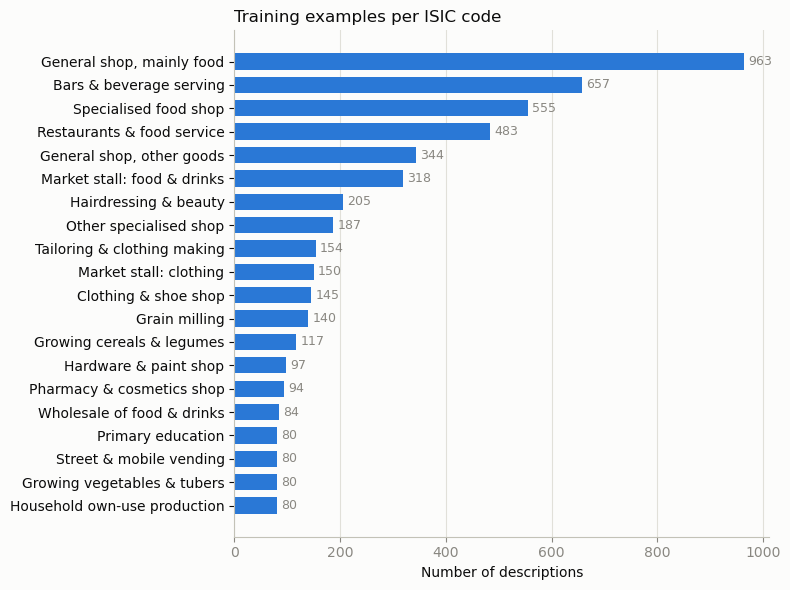

In [9]:
#@title How many examples per ISIC code? { display-mode: "form" }
counts = df[ISIC_LABEL].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(counts.index, counts.values, color=BLUE, height=0.7)
for y, v in enumerate(counts.values):
    ax.text(v + 8, y, f"{v:,}", va="center", color=MUTED, fontsize=9)
ax.set_xlabel("Number of descriptions")
ax.set_title("Training examples per ISIC code", loc="left", fontsize=12, color=INK)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 4 · Train The Model: The Whole Recipe In About 10 Lines
This is the same design as the production system:

* **Word TF-IDF** captures whole words such as *ubucuruzi* (trade) and *kogosha* (to cut hair).
* **Character TF-IDF** captures fragments of words, which makes it robust to misspellings
  (*ubucuruzi*, *ubucuri*, *ubucurizi*) and to Kinyarwanda word forms.
* **LinearSVC** with `class_weight="balanced"` so that rare codes still count.
* **CalibratedClassifierCV** turns the SVM's raw scores into **confidence scores** we can route on.

In [10]:
#@title Train the model (the code is the lesson, so it stays visible)
# ====
# Hold back 30% as unseen test data
# ====
X_train, X_test, y_train, y_test = train_test_split(
    df[CLEAN], df[ISIC_CODE], test_size=0.3, stratify=df[ISIC_CODE], random_state=42)

# ====
# Features -> classifier -> calibrated confidence
# ====
features = make_union(
    TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True),
)
model = make_pipeline(
    features,
    CalibratedClassifierCV(LinearSVC(class_weight="balanced", C=0.5), cv=3),
)
model.fit(X_train, y_train)
print(f"Trained on {len(X_train):,} descriptions, testing on {len(X_test):,} it has never seen.")

Trained on 3,509 descriptions, testing on 1,504 it has never seen.


## 5 · How Good Is It, And Where Does It Struggle?
**Accuracy** counts every record equally, so common codes dominate it.
**Macro F1** gives every code an equal vote, so weak performance on a rare code cannot hide.
ACMED uses Macro F1 to choose between models.

Accuracy : 0.68
Macro F1 : 0.72



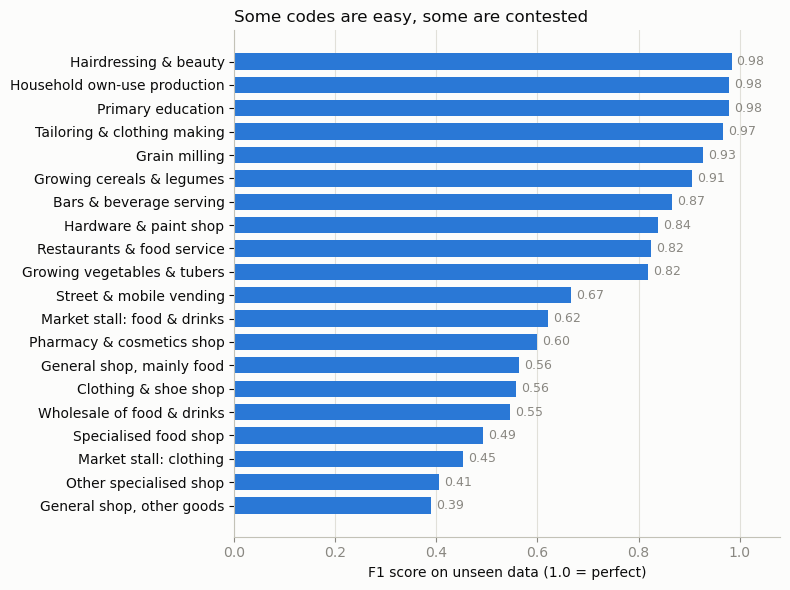

Most frequent mix-ups:


,true,predicted as,times
0,"General shop, mainly food",Specialised food shop,53
1,Specialised food shop,"General shop, mainly food",48
2,"General shop, other goods","General shop, mainly food",41
3,"General shop, mainly food","General shop, other goods",25
4,Market stall: clothing,Clothing & shoe shop,22


In [11]:
#@title Scores and the hardest codes { display-mode: "form" }
proba = model.predict_proba(X_test)
pred = model.classes_[proba.argmax(1)]
conf = proba.max(1)
truth = y_test.values

print(f"Accuracy : {accuracy_score(truth, pred):.2f}")
print(f"Macro F1 : {f1_score(truth, pred, average='macro'):.2f}\n")

# ====
# F1 per code
# ====
_, _, f1, _ = precision_recall_fscore_support(truth, pred, labels=model.classes_, zero_division=0)
per_code = pd.Series(f1, index=[LABEL[c] for c in model.classes_]).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(per_code.index, per_code.values, color=BLUE, height=0.7)
for y, v in enumerate(per_code.values):
    ax.text(v + 0.01, y, f"{v:.2f}", va="center", color=MUTED, fontsize=9)
ax.set_xlim(0, 1.08); ax.set_xlabel("F1 score on unseen data (1.0 = perfect)")
ax.set_title("Some codes are easy, some are contested", loc="left", fontsize=12, color=INK)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# ====
# Which codes get mixed up most often
# ====
mix = (pd.DataFrame({"true": truth, "pred": pred}).query("true != pred")
         .value_counts().head(5).reset_index(name="times"))
mix["true"] = mix["true"].map(LABEL); mix["predicted as"] = mix.pop("pred").map(LABEL)
print("Most frequent mix-ups:")
mix[["true", "predicted as", "times"]]

**What to notice:** the weakest codes are the different kinds of *shop*. A general shop, a
food shop and a general shop selling other goods are hard to tell apart from a short description,
and human coders disagree on them too. These are the cases we want a human to look at.

## 6 · Try To Fool It
Type a description in **Kinyarwanda, English or French**. The model returns its top 3 codes
with a confidence score, and the routing rule decides who makes the final call.
Try something vague (*"ubucuruzi"*, *"business"*) and something specific.

In [12]:
#@title Classify your own description { display-mode: "form" }
AUTO, REVIEW = 0.70, 0.50   # the production thresholds

def route(p, auto=AUTO, review=REVIEW):
    return "Auto-coded" if p >= auto else "Supervisor review" if p >= review else "Manual coding"

def classify(text, show=True):
    p = model.predict_proba([normalise(text)])[0]   # same cleaning as the training data
    top = p.argsort()[::-1][:3]
    lines = [f'"{text}"  ->  {route(p[top[0]]).upper()}']
    for i in top:
        lines.append(f"    {model.classes_[i]}  {LABEL[model.classes_[i]]:<30} {p[i]:5.0%}")
    if show: print("\n".join(lines) + "\n")

for example in ["kudoda imyenda", "gusya ibigori", "gucuruza imyenda", "ubucuruzi", "maize farmer"]:
    classify(example)

box = w.Text(placeholder="Type a job or business description…", layout=w.Layout(width="70%"))
btn = w.Button(description="Classify", button_style="primary")
out = w.Output()
def on_click(_):
    with out:
        out.clear_output(); classify(box.value.strip()) if box.value.strip() else print("Type something first.")
btn.on_click(on_click); box.on_submit(on_click)
display(w.HBox([box, btn]), out)

"kudoda imyenda"  ->  AUTO-CODED
    1410  Tailoring & clothing making      84%
    4771  Clothing & shoe shop              4%
    4711  General shop, mainly food         3%

"gusya ibigori"  ->  AUTO-CODED
    1061  Grain milling                    82%
    4711  General shop, mainly food         4%
    4773  Other specialised shop            2%

"gucuruza imyenda"  ->  SUPERVISOR REVIEW
    4771  Clothing & shoe shop             66%
    4782  Market stall: clothing           17%
    4711  General shop, mainly food         4%

"ubucuruzi"  ->  MANUAL CODING
    4719  General shop, other goods        31%
    4711  General shop, mainly food        17%
    4721  Specialised food shop            12%

"maize farmer"  ->  MANUAL CODING
    4711  General shop, mainly food        18%
    4773  Other specialised shop           10%
    4721  Specialised food shop            10%



Output()

**What to notice:**
* *kudoda imyenda* (sewing clothes) and *gusya ibigori* (milling maize) are specific, so they are **auto-coded**.
* *gucuruza imyenda* (selling clothes) is ambiguous: is it a clothing shop or a market stall?
  The model leans towards a shop with moderate confidence, so it goes to **supervisor review**.
* *ubucuruzi* ("trade") is too vague to code, so it goes to **manual coding**, which is the right outcome.
* *maize farmer* is **wrong**, but routing still sends it to a human. The model has seen almost no English,
  so language coverage in the training data is a fairness issue, not a technical detail.

## 7 · You Are The Regulator: Set The Thresholds
In production, ACMED auto-codes when confidence is **≥ 70%**, sends **50–70%** to a supervisor,
and sends anything **below 50%** to manual coding. Those numbers are a **policy choice**.
Move the sliders and watch the trade-off between how much gets automated and how many
errors pass through with **no human seeing them**.

*This demo model learned from only 5,000 records, so it is much less confident than the production
system, which was trained on about 390,000. The trade-off works the same way.*

In [13]:
#@title Confidence routing simulator { display-mode: "form" }
correct = pred == truth

def simulate(auto_threshold=0.70, review_threshold=0.50):
    review_threshold = min(review_threshold, auto_threshold)
    tier = np.where(conf >= auto_threshold, "Auto-coded",
                    np.where(conf >= review_threshold, "Supervisor review", "Manual coding"))
    share = {t: (tier == t).mean() for t in TIER_COLORS}

    # ====
    # One stacked bar: where 10,000 incoming records would go
    # ====
    fig, ax = plt.subplots(figsize=(9, 1.6))
    left = 0
    for t, c in TIER_COLORS.items():
        ax.barh(0, share[t], left=left, color=c, edgecolor="#fcfcfb", linewidth=2, height=0.6)
        if share[t] > 0.08:
            ax.text(left + share[t] / 2, 0, f"{t}\n{share[t]:.0%}", ha="center", va="center",
                    color="white" if t != "Manual coding" else INK, fontsize=9)
        elif share[t] > 0.03:
            ax.text(left + share[t] / 2, 0, f"{share[t]:.0%}", ha="center", va="center",
                    color="white" if t != "Manual coding" else INK, fontsize=9)
        left += share[t]
    ax.set_xlim(0, 1); ax.axis("off")
    ax.set_title(f"Auto-code at ≥ {auto_threshold:.0%} · review at ≥ {review_threshold:.0%}",
                 loc="left", fontsize=11, color=INK)
    plt.show()

    auto = tier == "Auto-coded"
    per10k = 10_000
    wrong_unseen = (auto & ~correct).mean() * per10k
    to_humans = (~auto).mean() * per10k
    acc_auto = correct[auto].mean() if auto.any() else float("nan")
    print(f"Accuracy of auto-coded records : {acc_auto:.0%}")
    print(f"Per 10,000 survey records:")
    print(f"   {auto.mean()*per10k:>6,.0f} coded automatically, of which ~{wrong_unseen:,.0f} are WRONG and no human sees them")
    print(f"   {to_humans:>6,.0f} go to a person (supervisor or manual coder)")

# ====
# A few settings side by side (a static view that also shows in a pre-run copy)
# ====
rows = []
for a, r in [(0.90, 0.70), (0.70, 0.50), (0.50, 0.30), (0.30, 0.10)]:
    auto = conf >= a
    rows.append({"Auto-code ≥": f"{a:.0%}", "Review ≥": f"{r:.0%}", "Automated": f"{auto.mean():.0%}",
                 "Accuracy when automated": f"{correct[auto].mean():.0%}" if auto.any() else "–",
                 "Wrong & unseen per 10k": f"{(auto & ~correct).mean()*10_000:,.0f}"})
display(pd.DataFrame(rows).set_index("Auto-code ≥"))

w.interact(simulate,
           auto_threshold=w.FloatSlider(value=0.70, min=0.30, max=0.95, step=0.05, description="Auto-code ≥",
                                        style={"description_width": "initial"}, readout_format=".0%"),
           review_threshold=w.FloatSlider(value=0.50, min=0.10, max=0.90, step=0.05, description="Review ≥",
                                          style={"description_width": "initial"}, readout_format=".0%"));

,Review ≥,Automated,Accuracy when automated,Wrong & unseen per 10k
Auto-code ≥,,,,
90%,70%,0%,100%,0
70%,50%,37%,92%,279
50%,30%,67%,81%,"1,277"
30%,10%,95%,70%,"2,806"


interactive(children=(FloatSlider(value=0.7, description='Auto-code ≥', max=0.95, min=0.3, readout_format='.0%…

## 8 · Your Call
**Put your answer in the chat:** *Which auto-code threshold would you approve for official statistics, and why?*

What the production system adds on top of this notebook:
* It is trained on **~390,000** records and **432** codes, not 5,000 records and 20 codes.
* The model is exported to **ONNX** and served from NISR's own infrastructure (aicoder.statistics.gov.rw).
* The **supervisor corrections** are fed back as a signal of where the model is drifting and are used for retraining.

## 9 · What Else Could We Try? Beyond TF-IDF: Language Models

Coding job descriptions is a **text-heavy task**, and TF-IDF has a hard limit: it matches
**words and word fragments, not meaning**. It doesn't know that *umuhinzi w'ibigori* and *maize farmer*
describe the same activity. That's why the English example failed above: the model had
almost no English to learn from. **Large language models (LLMs)** and other pretrained language models learn
meaning from huge amounts of text, so they can help exactly where our model struggles:

* **Meaning, not spelling:** they understand synonyms, paraphrases and descriptions they have never seen.
* **Many languages at once:** one model can relate Kinyarwanda, English and French descriptions to each other.
* **Rare codes:** they can use the official ISIC definitions, so a code with 5 training examples is not a lost cause.
* **Explanations:** they can say *why* they chose a code, which helps the supervisor reviewing the case.

### Options, From Simplest To Most Ambitious

| Approach | How it works | What it needs |
|---|---|---|
| **Multilingual embeddings + classifier** | Replace TF-IDF with sentence embeddings from a pretrained model, and keep the same classifier and calibration | A model that covers **Kinyarwanda** (many don't, so check), and a modest GPU or none |
| **Fine-tune an African-language model** | Retrain a model such as **AfroXLMR** (which covers Kinyarwanda) directly on the coded descriptions | A GPU, more engineering, and the full training data |
| **Prompt an LLM (zero- or few-shot)** | Give the LLM the description plus the list of ISIC codes and a few worked examples, and ask it to pick one | No training, but careful prompt design, and the LLM must only return **valid codes** |
| **Retrieval-augmented generation (RAG)** | For each new description: (1) **retrieve** the most similar already-coded descriptions and the relevant ISIC definitions, then (2) ask the LLM to choose a code **using that evidence** | A searchable index of past coded records and ISIC notes. This is a strong fit for official statistics because every decision cites its evidence |
| **Hybrid** | Keep the fast, cheap model for high-confidence records and use an LLM only for the **review tier**, as an assistant to the supervisor | Both systems, but the LLM runs on only a small share of records |

### The Governance Questions Come With The Model
A more powerful model does not remove the need for governance. It raises new questions:

* **Where does the data go?** Calling a commercial LLM API sends survey records outside national
  infrastructure. A self-hosted open model keeps them in-country but needs compute.
* **Can we still route by confidence?** LLMs often don't give reliable confidence scores, so
  confidence routing has to be redesigned and **re-validated**.
* **Is it reproducible?** A model provider can change the model behind an API without warning. If the model
  isn't pinned to a version, the same description can get a different code next month.
* **What does it cost?** A per-record API price multiplied by millions of survey records is a real budget line.
* **Is it actually better?** Any new approach should be judged on the **same held-out test set and
  the same metric (Macro F1)** before it replaces what works.

> This is where ACMED is heading: the team is testing whether newer architectures
> improve Macro F1 or calibration quality over the current pipeline. The standard stays the same:
> **a human keeps final authority over uncertain cases**, whatever model sits underneath.

← Back to the presentation.